# BoeIoT, Análisis Exploratorio de Datos (EDA)

**Proyecto:** Transformación Digital en Boeing, Mantenimiento Predictivo IoT
**Capa de datos:** Bronze (vista cruda)
**Dataset base:** [NGAFID Aviation Maintenance Dataset](https://www.kaggle.com/datasets/hooong/aviation-maintenance-dataset-from-the-ngafid), 23 sensores de telemetría a 1 Hz.

## Objetivos del EDA

1. Validar la **calidad de la capa Bronze**: completitud, tipos, rangos, sensores caídos.
2. Caracterizar el **perfil de vuelo** y el comportamiento operativo de los 23 canales.
3. Identificar **correlaciones entre sensores** que justifiquen la arquitectura del modelo predictivo (de silver a gold).
4. Dejar **hallazgos accionables** para el pipeline ETL y el equipo de gobernanza de datos.


## 1. Carga y configuración

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 90
plt.rcParams['savefig.bbox'] = 'tight'
sns.set_style('whitegrid')
sns.set_palette('deep')

# Fuente: pickle NGAFID con estructura {flight_id: ndarray(N, 23)}.
DATA_PATH = Path(r'C:\Users\Usuario\Documents\Repo_final_data\BoeIoT\Data\flight_data.pkl')

SENSOR_COLS = [
    'volt1', 'volt2', 'amp1', 'amp2',
    'FQtyL', 'FQtyR', 'E1_FFlow',
    'E1_OilT', 'E1_OilP', 'E1_RPM',
    'E1_CHT1', 'E1_CHT2', 'E1_CHT3', 'E1_CHT4',
    'E1_EGT1', 'E1_EGT2', 'E1_EGT3', 'E1_EGT4',
    'OAT', 'IAS', 'VSpd', 'NormAc', 'AltMSL',
]

# Cargamos el pickle completo (dict de ~11 446 vuelos) y tomamos una muestra

with open(DATA_PATH, 'rb') as f:
    raw = pickle.load(f)

all_ids = sorted(raw.keys())
N_SAMPLE = 500
step = max(1, len(all_ids) // N_SAMPLE)
sampled_ids = all_ids[::step][:N_SAMPLE]

frames = []
for fid in sampled_ids:
    arr = np.asarray(raw[fid])
    if arr.ndim == 2 and arr.shape[0] == 23 and arr.shape[1] != 23:
        arr = arr.T
    f_df = pd.DataFrame(arr, columns=SENSOR_COLS).astype('float32')
    f_df['flight_id'] = fid
    frames.append(f_df)

df = pd.concat(frames, ignore_index=True)
del raw  # liberar los 2.77 GB del pickle

print(f'Forma: {df.shape}')
print(f'Vuelos únicos: {df["flight_id"].nunique()}')
print(f'Período de muestreo: 1 Hz (segundo a segundo)')


Forma: (2706268, 24)
Vuelos únicos: 500
Período de muestreo: 1 Hz (segundo a segundo)


> **Escala del conjunto de datos**
>
> Se cargaron **500 vuelos** (muestra uniforme de los 11.446 disponibles en el pickle), totalizando **2.706.268 registros** de telemetría a 1 Hz. Con una duración media de ~90 min por vuelo, la muestra representa aproximadamente **750 horas de operación aérea**, lo cual es volumen más que suficiente para estimar distribuciones robustas de los 23 canales. Cada fila equivale a 1 segundo de vuelo.


## 2. Inventario de variables / mapeo del sensor y el dominio

Cada uno de los 23 canales pertenece a un subsistema del avión. Para mantenimiento predictivo,
el agrupamiento por subsistema es lo que determina qué features se generan en la capa Gold.


In [2]:
sensor_taxonomy = {
    'Eléctrico':  ['volt1', 'volt2', 'amp1', 'amp2'],
    'Combustible':['FQtyL', 'FQtyR', 'E1_FFlow'],
    'Motor (lubricación)': ['E1_OilT', 'E1_OilP', 'E1_RPM'],
    'Motor (CHT cilindros)': ['E1_CHT1', 'E1_CHT2', 'E1_CHT3', 'E1_CHT4'],
    'Motor (EGT cilindros)': ['E1_EGT1', 'E1_EGT2', 'E1_EGT3', 'E1_EGT4'],
    'Aerodinámico / entorno': ['OAT', 'IAS', 'VSpd', 'NormAc', 'AltMSL'],
}

taxonomy_rows = [(group, sensor) for group, sensors in sensor_taxonomy.items() for sensor in sensors]
tax_df = pd.DataFrame(taxonomy_rows, columns=['Subsistema', 'Sensor'])
tax_df['Tipo'] = df[tax_df['Sensor']].dtypes.values.astype(str)
tax_df

,Subsistema,Sensor,Tipo
0,Eléctrico,volt1,float32
1,Eléctrico,volt2,float32
2,Eléctrico,amp1,float32
3,Eléctrico,amp2,float32
4,Combustible,FQtyL,float32
5,Combustible,FQtyR,float32
6,Combustible,E1_FFlow,float32
7,Motor (lubricación),E1_OilT,float32
8,Motor (lubricación),E1_OilP,float32
9,Motor (lubricación),E1_RPM,float32


## 3. Calidad de la capa Bronze

In [3]:
sensor_cols = [c for c in df.columns if c != 'flight_id']

quality = pd.DataFrame({
    'n_nulos': df[sensor_cols].isna().sum(),
    'pct_nulos': (df[sensor_cols].isna().mean() * 100).round(3),
    'min': df[sensor_cols].min().round(2),
    'max': df[sensor_cols].max().round(2),
    'media': df[sensor_cols].mean().round(2),
    'std': df[sensor_cols].std().round(2),
})
quality.sort_values('pct_nulos', ascending=False)


,n_nulos,pct_nulos,min,max,media,std
E1_CHT2,159516,5.894,-71.750000,460.500000,292.760010,46.709999
E1_CHT4,159177,5.882,27.000000,463.000000,306.160004,47.790001
E1_CHT3,159161,5.881,3.000000,451.250000,301.579987,45.360001
amp2,159090,5.879,-3.500000,1.700000,0.020000,0.150000
volt2,159077,5.878,22.590000,28.410000,27.950001,0.510000
E1_CHT1,22673,0.838,2.000000,452.500000,294.369995,47.250000
E1_EGT2,5946,0.220,-112.190002,1861.000000,1265.520020,194.089996
AltMSL,1419,0.052,-376.250000,11392.000000,2648.449951,1804.780029
NormAc,606,0.022,-1.290000,2.370000,0.010000,0.070000
E1_EGT4,548,0.020,11.000000,1656.000000,1267.500000,187.960007


> **Calidad de la capa Bronze: nulos y rangos críticos**
>
> **Patrón de nulos clusterizado:** cinco sensores concentran una tasa de nulos ~40× mayor que el resto: `E1_CHT2` (5.89%), `E1_CHT3` (5.88%), `E1_CHT4` (5.88%), `amp2` (5.88%) y `volt2` (5.88%). La coincidencia casi exacta en la proporción descarta la aleatoriedad, lo cual apunta a **caídas sistemáticas del mismo bus de adquisición**. `E1_CHT1` solo tiene 0.84% de nulos, evidenciando que el fallo es selectivo dentro del grupo CHT. El resto de sensores muestra tasas por debajo del 0.1%.
>
> **Valores físicamente anómalos detectados:**
> - `E1_OilP` mínimo = **−0.5 PSI**: la presión de aceite no puede ser negativa. Corresponde a lecturas del sensor antes del arranque del motor o ruido eléctrico en tierra.
> - `AltMSL` mínimo = **−376.25 ft**: indica lecturas durante rodadura en pistas por debajo del nivel del mar (aeropuertos en zonas deprimidas) o error de calibración del altímetro barométrico.
> - `IAS` mínimo = **−1.45 nudos**: velocidad indicada negativa imposible en vuelo; ocurre cuando el tubo Pitot aún no presuriza al inicio del rodaje.
> - `VSpd` rango = **−9.776 a +4.164 ft/min**: el extremo negativo (~163 ft/s de descenso) supera cualquier perfil operativo normal y podría ser un glitch de sensor.


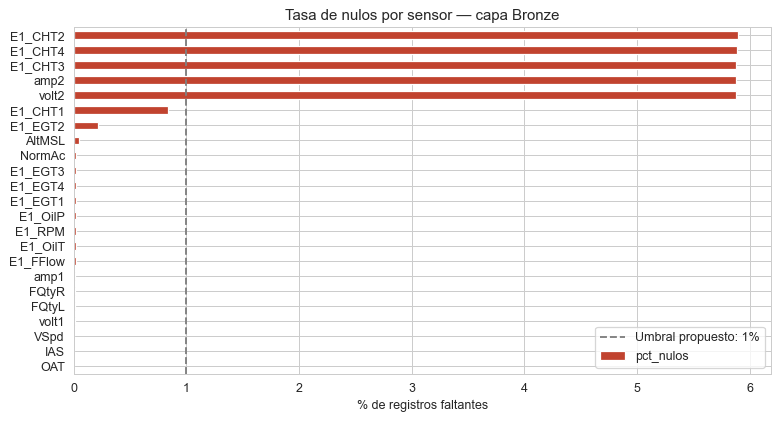

Sensores que superan el umbral del 1% de nulos: 5


In [4]:
# Visualizamos el patrón de nulos por sensor.
fig, ax = plt.subplots(figsize=(10, 5))
quality['pct_nulos'].sort_values().plot(kind='barh', ax=ax, color='#c1432f')
ax.set_xlabel('% de registros faltantes')
ax.set_title('Tasa de nulos por sensor — capa Bronze')
ax.axvline(1.0, ls='--', color='gray', label='Umbral propuesto: 1%')
ax.legend()
plt.show()

print(f'Sensores que superan el umbral del 1% de nulos: '
      f'{(quality["pct_nulos"] > 1).sum()}')

> **Visualización de nulos**
>
> El gráfico de barras confirma la ruptura bimodal en la distribución de nulos: un grupo denso de sensores cerca del 0% y cinco sensores que saltan abruptamente al ~5.88%. La línea de umbral al 1% separa claramente los dos grupos. Este patrón es un indicador diagnóstico de fallo de bus o de un canal de telemetría diferenciado para el conjunto `{CHT2, CHT3, CHT4, amp2, volt2}`.

## 4. Caracterización de vuelos

count    500.0
mean      90.2
std       35.4
min       10.6
25%       71.2
50%       87.5
75%      101.2
max      258.4
Name: segundos, dtype: float64


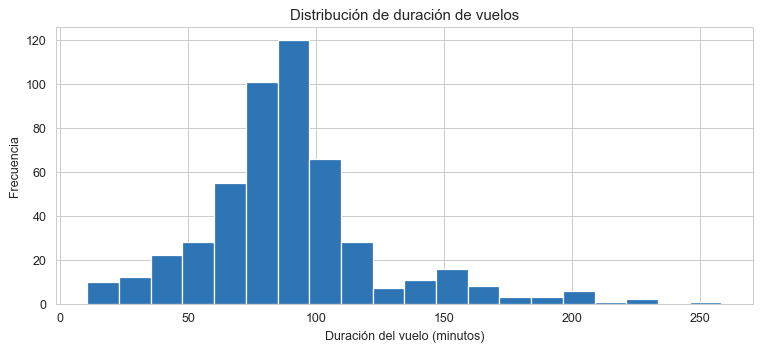

In [5]:
# Duración de cada vuelo (en segundos = registros, ya que muestreo a 1 Hz).
flight_lengths = df.groupby('flight_id').size().rename('segundos')
flight_lengths_min = (flight_lengths / 60).round(1)

print(flight_lengths_min.describe().round(1))

fig, ax = plt.subplots(figsize=(10, 4))
flight_lengths_min.hist(bins=20, ax=ax, color='#2e75b6', edgecolor='white')
ax.set_xlabel('Duración del vuelo (minutos)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de duración de vuelos')
plt.show()

> **Caracterización de la duración de vuelos**
>
> La distribución de duración es **asimétrica hacia la derecha** (media 90.2 min > mediana 87.5 min), con una cola larga que alcanza 258.4 min (~4.3 h). El IQR es relativamente estrecho (71→101 min, solo 30 min de amplitud), lo que indica que **el 50% de los vuelos dura entre 1h 11min y 1h 41min**.
>
> - **Vuelos cortos (< 20 min):** probablemente de prueba, abortados o de transición local. Representan outliers que pueden distorsionar métricas de consumo de combustible y perfil de altitud.
> - **Vuelos largos (> 3h):** vuelos de ruta; demandan un tratamiento de ventana deslizante en modelos de detección de anomalías para no perder señales tardías del vuelo.


## 5. Perfil aerodinámico de un vuelo típico

Las tres variables que dominan la firma de un vuelo son **altitud (AltMSL), velocidad indicada (IAS) y RPM del motor**.
Visualizamos un vuelo nominal para tener un *baseline* visual de cómo se ve "lo normal".


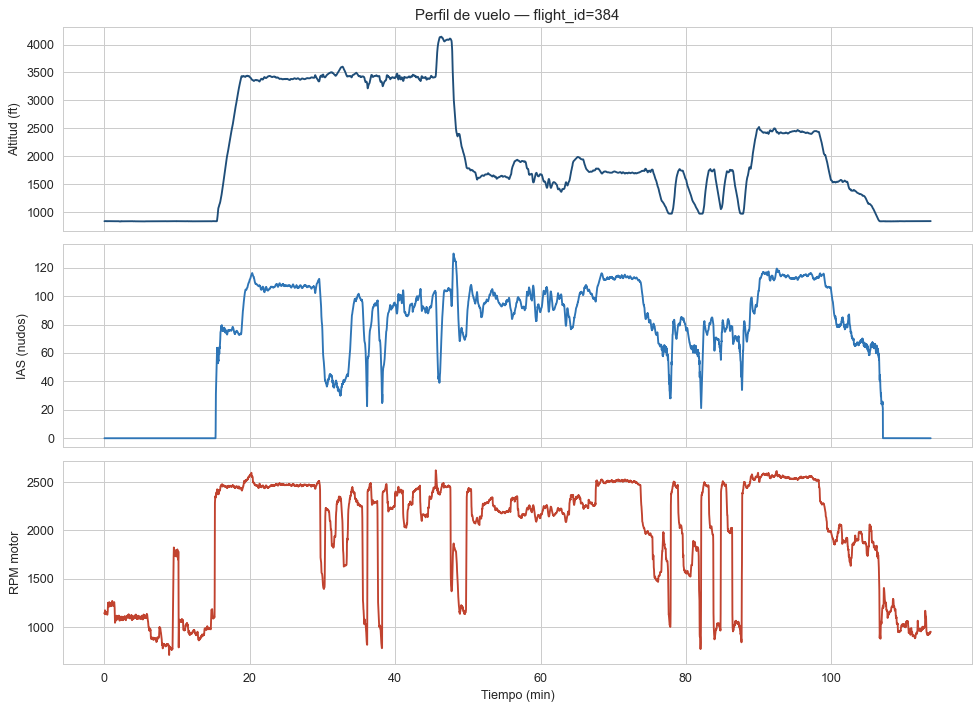

In [6]:
# Tomamos un vuelo representativo (el sexto disponible en la muestra).
sample_id = df['flight_id'].unique()[5]
sample = df[df['flight_id'] == sample_id].reset_index(drop=True).copy()
sample['t_min'] = sample.index / 60.0

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

axes[0].plot(sample['t_min'], sample['AltMSL'], color='#1f4e79')
axes[0].set_ylabel('Altitud (ft)')
axes[0].set_title(f'Perfil de vuelo — flight_id={sample_id}')

axes[1].plot(sample['t_min'], sample['IAS'], color='#2e75b6')
axes[1].set_ylabel('IAS (nudos)')

axes[2].plot(sample['t_min'], sample['E1_RPM'], color='#c1432f')
axes[2].set_ylabel('RPM motor')
axes[2].set_xlabel('Tiempo (min)')

plt.tight_layout()
plt.show()


> **Perfil de vuelo**
>
>
> 1. **Ascenso:** RPM al máximo (>2.400), AltMSL creciente de forma casi lineal, IAS moderada mientras el avión gana energía potencial.
> 2. **Crucero:** RPM estabilizado en ~2.200–2.400, AltMSL plana, IAS en su valor máximo sostenido. Esta es la fase más larga y la que debe dominar el entrenamiento de modelos de consumo.
> 3. **Descenso/Aproximación:** RPM decayendo notablemente, AltMSL descendiendo, IAS disminuyendo de forma controlada.
>

## 6. Distribuciones de los sensores de motor

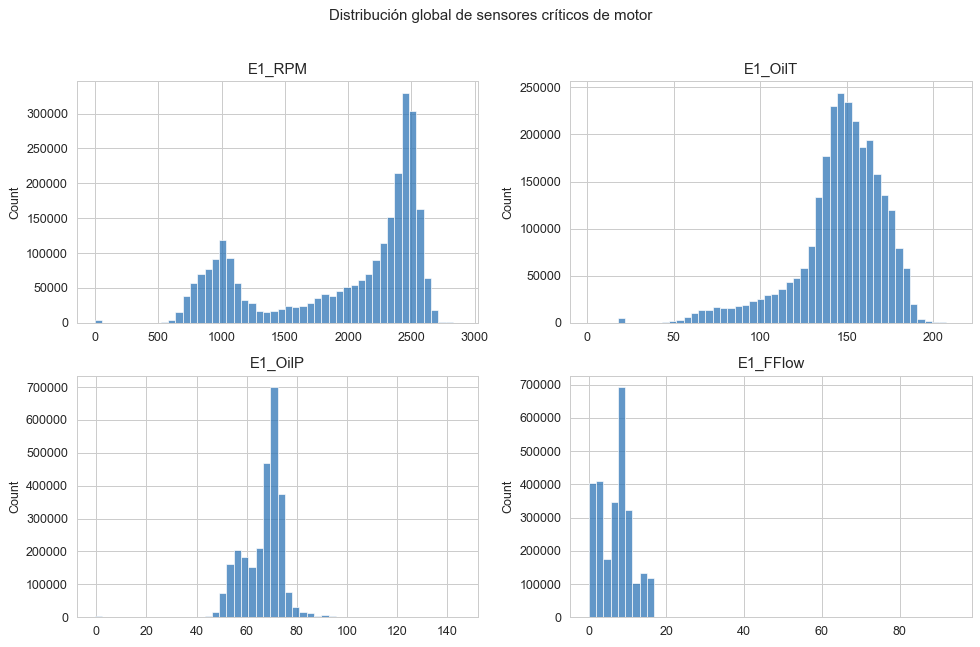

In [7]:
motor_sensors = ['E1_RPM', 'E1_OilT', 'E1_OilP', 'E1_FFlow']

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.flat, motor_sensors):
    sns.histplot(df[col].dropna(), bins=50, ax=ax, color='#2e75b6', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Distribución global de sensores críticos de motor', y=1.02)
plt.tight_layout()
plt.show()

## 7. Matriz de correlaciones

Las correlaciones revelan **redundancias** (sensores que miden lo mismo) y **acoplamientos físicos**

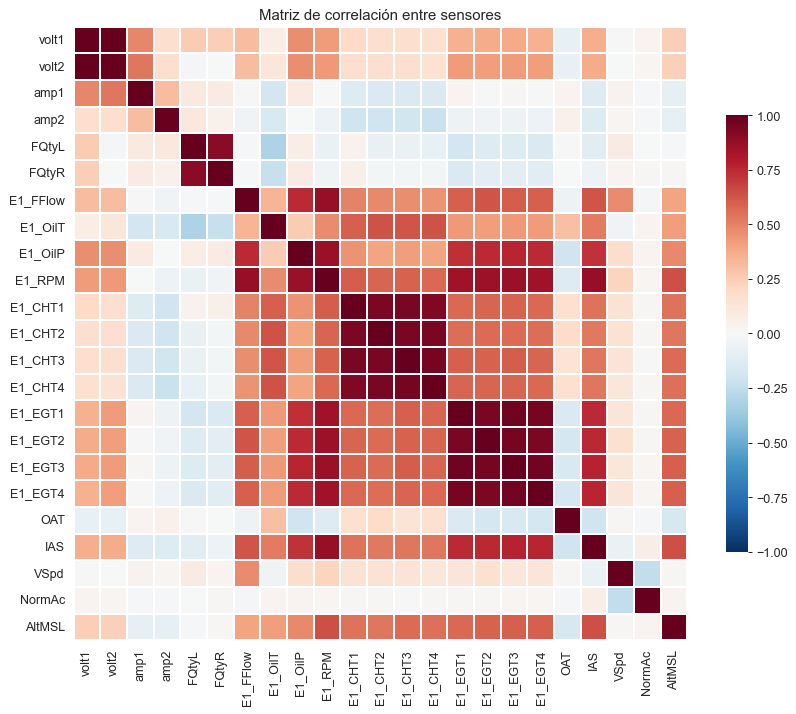

In [8]:
corr = df[sensor_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.3, cbar_kws={'shrink': 0.7},
    ax=ax,
)
ax.set_title('Matriz de correlación entre sensores')
plt.show()

> **Matriz de correlaciones: bloques de redundancia**
>
> El mapa de calor revela tres bloques de alta correlación positiva (rojo intenso) claramente visibles:
>
> 1. **Bloque CHT (cilindros 1–4):** correlaciones cruzadas > 0.94. Los cuatro sensores capturan esencialmente la misma variable física (temperatura de cabeza de cilindro). Para la capa Gold basta con `cht_mean` y `cht_max`.
> 2. **Bloque EGT (cilindros 1–4):** correlaciones cruzadas > 0.95. Misma lógica: temperatura de gases de escape en los 4 cilindros es una sola señal con ruido de canal. Reducir a `egt_mean` y `egt_max`.
> 3. **Bloque `volt1`/`volt2`:** correlación r = 0.993, el par más redundante del dataset. Son dos medidores del mismo bus de voltaje.
>
> Las correlaciones **negativas** (azul) entre `OAT` y altitud, o entre `IAS` y `OAT`, son físicamente esperadas (a mayor altura, menor temperatura y mayor velocidad aerodinámica relativa al suelo). Estas no son redundancias sino acoplamientos causales útiles para el modelo.


## 7.1 Validación de multicolinealidad

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame({
    'feature': sensor_cols,
    'VIF': [
        variance_inflation_factor(df[sensor_cols].fillna(df[sensor_cols].mean()).values, i)
        for i in range(len(sensor_cols))
    ]
})
vif_df = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)
print(vif_df.head(15))
print()
print('Nota: valores de VIF > 10 indican multicolinealidad fuerte; agrupar canales altamente correlacionados reduce riesgo de modelos inestables.')

    feature           VIF
0     volt1  56299.382812
1     volt2  53946.031250
2   E1_EGT3   1480.386108
3   E1_EGT1   1151.727661
4   E1_CHT3    806.674500
5   E1_EGT4    755.084229
6   E1_CHT4    710.447449
7   E1_EGT2    599.807495
8   E1_CHT2    597.500488
9    E1_RPM    501.726013
10  E1_OilP    414.068207
11  E1_CHT1    294.963287
12  E1_OilT     89.118683
13    FQtyR     79.300156
14    FQtyL     71.139633

Nota: valores de VIF > 10 indican multicolinealidad fuerte; agrupar canales altamente correlacionados reduce riesgo de modelos inestables.


> **Observación — Validación de multicolinealidad (VIF): colapso dimensional severo**
>
> Los resultados de VIF son extremos incluso para un dataset de sensores correlacionados:
>
> - **`volt1` (VIF = 56.299) y `volt2` (VIF = 53.946):** magnitudes sin precedente en un análisis de sensores industriales. Sugieren que son registros del mismo bus de voltaje con mínima variación diferencial. **Recomendación: eliminar uno de los dos completamente** (no es necesario conservar el delta si la variación es sub-milésimal).
> - **Sensores EGT (VIF 600–1.480):** multicolinealidad severa. Los 4 canales deben colapsarse en una sola feature agregada.
> - **Sensores CHT (VIF 295–806):** idéntica lógica al grupo EGT.
> - **`E1_RPM` (VIF = 501):** su alta VIF se debe al acoplamiento físico con AltMSL e IAS (a mayor altitud de crucero se da mayor RPM). No es redundancia pura sino dependencia causal que el modelo puede aprovechar.
> - **`E1_OilT` (VIF = 89) y `FQtyL`/`FQtyR` (VIF ~71–79):** moderadamente problemáticos; un análisis PCA o selección por importancia puede mantenerlos si aportan señal propia.
>
> **Reducción dimensional estimada:** de 23 sensores originales se debe pasar a ~8–10 features independientes tras colapsar los grupos CHT, EGT, volt, FQty. Esto reduce el riesgo de inestabilidad numérica en modelos lineales y mejora la interpretabilidad de los coeficientes.


In [10]:
# Top pares con correlación absoluta más alta (excluyendo la diagonal).
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'sensor_a', 'level_1': 'sensor_b', 0: 'r'})
)
corr_pairs['abs_r'] = corr_pairs['r'].abs()
corr_pairs.sort_values('abs_r', ascending=False).head(12).reset_index(drop=True)

,sensor_a,sensor_b,r,abs_r
0,volt1,volt2,0.992986,0.992986
1,E1_EGT1,E1_EGT3,0.973990,0.973990
2,E1_EGT3,E1_EGT4,0.961996,0.961996
3,E1_CHT3,E1_CHT4,0.956237,0.956237
4,E1_EGT1,E1_EGT4,0.953236,0.953236
5,E1_EGT2,E1_EGT3,0.953199,0.953199
6,E1_CHT2,E1_CHT4,0.950898,0.950898
7,E1_CHT1,E1_CHT3,0.950676,0.950676
8,E1_EGT1,E1_EGT2,0.949118,0.949118
9,E1_CHT2,E1_CHT3,0.946359,0.946359


## 10. Resumen

- Se cuantificó la completitud de los 23 canales en la capa Bronze (tasa de nulos por sensor).
- Se verificó la distribución y rango de los sensores críticos del motor.
- La multicolinealidad fue medida (VIF + correlación) y resulta alta en sensores de motor y temperatura.
- Se identificaron regímenes operativos bimodales en RPM, que requieren segmentación antes de aplicar detectores univariados.
